# 6. SLI 통합분석: DTW 클러스터링 + 생존분석 + ML

> **목표:** 데이터 기반 다중 방법론(DTW 클러스터링, 생존분석, 검색트렌드, ML)을 통합한 연착륙 상품 판별 파이프라인을 구축한다.

---

In [298]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from sklearn.metrics import silhouette_score
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, f1_score,
    precision_recall_curve, confusion_matrix
)
import shap
import ruptures as rpt

# 시각화 설정
plt.rcParams['font.family'] = 'Noto Sans KR'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# 컬러 팔레트
COLORS = {
    'primary': '#2563EB',
    'positive': '#16A34A',
    'negative': '#DC2626',
    'neutral': '#F59E0B',
    'accent': '#7C3AED',
    'gray': '#6B7280'
}

In [299]:
# 설정 (Configuration)

import os

PROJECT_ROOT = '/Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi'
PARQUET_DIR = os.path.join(PROJECT_ROOT, '02_outputs/data/parquet/analysis_parquet')
ABSA_DIR = os.path.join(PROJECT_ROOT, '06_analysis/03_ABSA/01_outputs/snapshot/stage3a_v3_20260225')
SEARCH_DIR = os.path.join(PROJECT_ROOT, '06_analysis/04_search_trend/01_outputs')
FIGURE_DIR = os.path.join(PROJECT_ROOT, '02_outputs/figures/SLI')
os.makedirs(FIGURE_DIR, exist_ok=True)

# 분석 파라미터
MAX_MONTH = 12          # 최대 분석 기간 (개월)
MIN_TOTAL_REVIEWS = None  # 동적 계산: 전체 상품 리뷰수의 25th percentile (셀 6에서 자동 설정)
DEATH_THRESHOLD = 0.3  # 피크 대비 사망 기준 (30%) — 기존 20%에서 보수적 상향
DEATH_CONSECUTIVE = 2   # 연속 하회 개월 수
STOCKOUT_CONSECUTIVE = 2  # 품절 판단 연속 0-리뷰 개월
K_RANGE = range(3, 8)   # DTW 클러스터 수 탐색 범위
RANDOM_STATE = 42

# 연착륙 수 조절용 기준 (값을 올리면 연착륙 상품 수 감소)
SURVIVAL_QUANTILE = 0.75   # 생존분석: duration이 이 분위수 초과만 연착륙 (0.5=중앙→50%, 0.75=상위 25%)
FINAL_AGREEMENT_MIN = 4    # 최종 연착륙: 4개 방법 중 N개 이상 동의 (4=만장일치만)
RETENTION_LATE_RATIO = 0.6 # 규칙기반: 후기/초기 비율 하한 (0.5→0.6으로 강화)
RETENTION_MID_RATIO = 0.7  # 규칙기반: 중기/초기 비율 하한 (0.6→0.7로 강화)
SLOPE_MIN = -0.5           # 규칙기반: 기울기 하한 (-1.0→-0.5로 강화, 급하락 불허)
MAX_SOFT_LANDING_PRODUCTS = None  # 최종 리스트 상한 (None=미적용, 100 등 숫자면 상위 N개만)

In [300]:
# 1. 데이터 로드

# --- Parquet 데이터 ---
products = pd.read_parquet(os.path.join(PARQUET_DIR, 'products_full.parquet'))
reviews = pd.read_parquet(os.path.join(PARQUET_DIR, 'reviews_full.parquet'))
ingredients = pd.read_parquet(os.path.join(PARQUET_DIR, 'ingredients_full.parquet'))
users = pd.read_parquet(os.path.join(PARQUET_DIR, 'users_full.parquet'))

# --- ABSA 데이터 ---
absa_review = pd.read_csv(os.path.join(ABSA_DIR, 'review_level.csv'))
absa_product = pd.read_csv(os.path.join(ABSA_DIR, 'product_kpi.csv'))

# --- 검색트렌드 데이터 ---
search_brand = pd.read_csv(os.path.join(SEARCH_DIR, 'search_trend_all-brand_finals_20260225.csv'))
search_segment = pd.read_csv(os.path.join(SEARCH_DIR, 'search_trend_all-brand_segment_20260225.csv'))

# 검색트렌드 제품 데이터
search_product_path = os.path.join(SEARCH_DIR, 'search_trend_product_finals_20260225.csv')
if os.path.exists(search_product_path):
    search_product = pd.read_csv(search_product_path)
    print(f"  검색트렌드(제품): {search_product.shape}")
else:
    search_product = None
    print("  검색트렌드(제품): 파일 없음")

print(f"\n{'='*50}")
print(f"데이터 로드 완료")
print(f"{'='*50}")
print(f"  상품: {products.shape}")
print(f"  리뷰: {reviews.shape}")
print(f"  성분: {ingredients.shape}")
print(f"  사용자: {users.shape}")
print(f"  ABSA(리뷰): {absa_review.shape}")
print(f"  ABSA(상품): {absa_product.shape}")
print(f"  검색트렌드(브랜드): {search_brand.shape}")
print(f"  검색트렌드(세그먼트): {search_segment.shape}")

  검색트렌드(제품): (520, 6)

데이터 로드 완료
  상품: (948, 21)
  리뷰: (323114, 10)
  성분: (27975, 11)
  사용자: (25531, 8)
  ABSA(리뷰): (323114, 18)
  ABSA(상품): (937, 38)
  검색트렌드(브랜드): (738, 6)
  검색트렌드(세그먼트): (10929, 5)


In [301]:
print("=" * 60)
print("Products 컬럼")
print("=" * 60)
print(products.columns.tolist())
print(f"\n가격 분포:\n{products['price'].describe()}")

print("\n" + "=" * 60)
print("Reviews 컬럼")
print("=" * 60)
print(reviews.columns.tolist())

# 날짜 컬럼 확인
date_cols = [c for c in reviews.columns if 'date' in c.lower() or 'time' in c.lower()]
print(f"\n날짜 관련 컬럼: {date_cols}")
if len(date_cols) > 0:
    col = date_cols[0]
    reviews[col] = pd.to_datetime(reviews[col])
    print(f"  {col} 범위: {reviews[col].min()} ~ {reviews[col].max()}")

print("\n" + "=" * 60)
print(" ABSA Product KPI 컬럼")
print("=" * 60)
print(absa_product.columns.tolist())
absa_product.head(3)

Products 컬럼
['product_code', 'name', 'brand_name', 'manufacturer_name', 'price', 'country', 'category_1', 'category_2', 'likes', 'shares', 'review_count', 'engagement_score', 'cp_index', 'review_density', 'first_review_date', 'ITEM_PH', 'ph_category', 'is_whitening', 'is_wrinkle_reduction', 'is_sunscreen', 'is_acne']

가격 분포:
count     948.000000
mean     3713.607595
std      1277.080249
min       500.000000
25%      3000.000000
50%      3000.000000
75%      5000.000000
max      5000.000000
Name: price, dtype: float64

Reviews 컬럼
['review_id', 'product_code', 'user_id', 'rating', 'review_date', 'text', 'review_length', 'image_count', 'is_reorder', 'promotion_id']

날짜 관련 컬럼: ['review_date']
  review_date 범위: 2024-01-01 00:00:00 ~ 2026-02-10 00:00:00

 ABSA Product KPI 컬럼
['product_code', 'n_reviews', 'brand_id', 'product_name', 'price', 'brand_name', 'category_1', 'category_2', 'overall_pos_rate', 'overall_neu_rate', 'overall_neg_rate', 'mention_rate_가격/가성비', 'mention_rate_디자인', 'mention

,product_code,n_reviews,brand_id,product_name,price,brand_name,category_1,category_2,overall_pos_rate,overall_neu_rate,...,neg_count_디자인,neg_count_배송/포장,neg_count_사용감/성능,neg_count_색상/발색,neg_count_용량/휴대,neg_count_재구매,neg_count_재질/냄새,repurchase_mention_rate,ambiguous_rate,uncategorized_rate
0,1049276,9504,41,VT 리들샷 300 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어,0.636995,0.329861,...,0.0,38.0,273.0,0.0,14.0,3.0,3.0,0.055135,0.051242,0.0
1,1049275,9489,41,VT 리들샷 100 페이셜 부스팅 퍼스트 앰플 2ml*6개입,3000.0,VT,스킨케어,기초스킨케어,0.666245,0.313732,...,1.0,11.0,164.0,0.0,12.0,0.0,3.0,0.063969,0.048583,0.0
2,1061918,5758,48,본셉 비타씨 동결 건조 더블샷 앰플 키트,5000.0,본셉,스킨케어,기초스킨케어,0.642932,0.328413,...,6.0,15.0,98.0,0.0,36.0,2.0,6.0,0.091177,0.053838,0.0


---
## 2. 전처리: 월별 시계열 구성

### 핵심 설계
- **역월(Calendar Month)** 기준 집계 (`pd.to_period('M')`)  — `days // 30`보다 정확
- **품절 감지:** 연속 2개월 이상 리뷰 0건 → 품절 플래그 부여, 사망 판단에서 제외
- **프로모션 매핑:** 리뷰의 프로모션 이벤트 비율을 월별로 집계

In [302]:
# 2. 월별 시계열 구성

# 리뷰 날짜 컬럼 확인 및 변환
date_col = [c for c in reviews.columns if 'date' in c.lower() or 'time' in c.lower()][0]
reviews['review_date'] = pd.to_datetime(reviews[date_col])
reviews['review_month'] = reviews['review_date'].dt.to_period('M')

# 상품별 월별 리뷰 수 집계
agg_dict = {
    'review_date': 'size',
    'rating': 'mean',
}
if 'is_reorder' in reviews.columns:
    agg_dict['is_reorder'] = 'sum'

monthly_reviews = (
    reviews
    .groupby(['product_code', 'review_month'])
    .agg(**{
        'review_count': ('review_date', 'size'),
        'avg_rating': ('rating', 'mean'),
    })
    .reset_index()
)

# 상품별 첫 리뷰 월
first_month = monthly_reviews.groupby('product_code')['review_month'].min().reset_index()
first_month.columns = ['product_code', 'first_month']

monthly_reviews = monthly_reviews.merge(first_month, on='product_code')

# 상대 월 계산 (첫 리뷰 = 0)
monthly_reviews['relative_month'] = (
    (monthly_reviews['review_month'] - monthly_reviews['first_month'])
    .apply(lambda x: x.n)
)

# MAX_MONTH 이내만 유지
monthly_reviews = monthly_reviews[monthly_reviews['relative_month'] < MAX_MONTH]

# 전체 기간 채우기 (결측 월 = 0)
all_products = monthly_reviews['product_code'].unique()
filled_rows = []
for pc in all_products:
    sub = monthly_reviews[monthly_reviews['product_code'] == pc]
    max_rel = min(sub['relative_month'].max(), MAX_MONTH - 1)
    for m in range(int(max_rel) + 1):
        row = sub[sub['relative_month'] == m]
        if len(row) > 0:
            filled_rows.append({
                'product_code': pc,
                'relative_month': m,
                'review_count': row['review_count'].values[0],
                'avg_rating': row['avg_rating'].values[0],
            })
        else:
            filled_rows.append({
                'product_code': pc,
                'relative_month': m,
                'review_count': 0,
                'avg_rating': np.nan,
            })

ts_df = pd.DataFrame(filled_rows)

# 최소 리뷰 수 필터: 전체 상품 리뷰수의 25th percentile 기준
total_reviews = ts_df.groupby('product_code')['review_count'].sum().reset_index()
total_reviews.columns = ['product_code', 'total_reviews']

if MIN_TOTAL_REVIEWS is None:
    MIN_TOTAL_REVIEWS = int(total_reviews['total_reviews'].quantile(0.25))
    print(f" 최소 리뷰수 자동 설정: 전체 상품 리뷰수의 25th percentile = {MIN_TOTAL_REVIEWS}건")

valid_products = total_reviews[total_reviews['total_reviews'] >= MIN_TOTAL_REVIEWS]['product_code']
ts_df = ts_df[ts_df['product_code'].isin(valid_products)]

# 품절 감지: 연속 2개월 이상 리뷰 0건
def detect_stockout(group):
    counts = group.sort_values('relative_month')['review_count'].values
    stockout = np.zeros(len(counts), dtype=bool)
    consecutive_zeros = 0
    for i, c in enumerate(counts):
        if c == 0:
            consecutive_zeros += 1
        else:
            consecutive_zeros = 0
        if consecutive_zeros >= STOCKOUT_CONSECUTIVE:
            for j in range(i - consecutive_zeros + 1, i + 1):
                stockout[j] = True
    return pd.Series(stockout, index=group.index)

ts_df = ts_df.sort_values(['product_code', 'relative_month'])
ts_df['is_stockout'] = ts_df.groupby('product_code', group_keys=False).apply(detect_stockout)

print(f"월별 시계열 구성 완료")
print(f"  유효 상품 수: {ts_df['product_code'].nunique()}")
print(f"  총 레코드 수: {len(ts_df)}")
print(f"  품절 플래그 비율: {ts_df['is_stockout'].mean():.1%}")

 최소 리뷰수 자동 설정: 전체 상품 리뷰수의 25th percentile = 59건
월별 시계열 구성 완료
  유효 상품 수: 706
  총 레코드 수: 7342
  품절 플래그 비율: 0.5%


---
## 3. DTW 시계열 클러스터링

### 방법론
- **DTW (Dynamic Time Warping):** 시간축 왜곡을 허용하는 시계열 유사도 측정 → 위상(phase) 차이에 강건
- **TimeSeriesKMeans (tslearn):** DTW 거리 기반 k-Means 클러스터링
- **최적 k 탐색:** Silhouette Score 기준 (k = 3~7)
- **클러스터 자동 라벨링:** 센트로이드 기울기 + 후반부 유지율 기반

### 기대 패턴
| 패턴 | 특징 | 연착륙 여부 |
|------|------|-------------|
| 급락형 | Early 피크 후 급격 하락 | X |
| 점진하락형 | 서서히 감소 | 조건부 |
| 안정유지형 | 일정 수준 유지 | O |
| 후기상승형 | 후반에 상승 | O |

In [303]:
# 3. DTW 시계열 클러스터링

# 시계열 행렬 구성 (상품 x 월)
pivot = ts_df.pivot_table(
    index='product_code', columns='relative_month',
    values='review_count', fill_value=0
)

# 동일 길이로 맞추기 (MAX_MONTH)
max_cols = MAX_MONTH
if pivot.shape[1] < max_cols:
    for m in range(pivot.shape[1], max_cols):
        pivot[m] = 0
pivot = pivot[list(range(max_cols))]

product_codes = pivot.index.tolist()
ts_matrix = pivot.values.astype(float)

# Min-Max 정규화 (상품별, 0 ~ 1)
row_max = ts_matrix.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1  # 0 방지
ts_normed = ts_matrix / row_max

# tslearn 형식 변환
ts_dataset = to_time_series_dataset(ts_normed)

print(f"시계열 행렬: {ts_matrix.shape} (상품 x 월)")
print(f"  정규화 완료: min={ts_normed.min():.2f}, max={ts_normed.max():.2f}")

# 최적 k 탐색 (Silhouette Score)
sil_scores = {}
models = {}
for k in K_RANGE:
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric='dtw',
        max_iter=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    labels = model.fit_predict(ts_dataset)

    # Silhouette Score 계산 (유클리드 근사)
    score = silhouette_score(ts_normed, labels, metric='euclidean')
    sil_scores[k] = score
    models[k] = (model, labels)
    print(f"  k={k}: Silhouette = {score:.4f}")

# 최적 k 선택
best_k = max(sil_scores, key=sil_scores.get)
best_model, best_labels = models[best_k]
print(f"\n최적 클러스터 수: k={best_k} (Silhouette={sil_scores[best_k]:.4f})")

# 클러스터 할당
cluster_df = pd.DataFrame({
    'product_code': product_codes,
    'dtw_cluster': best_labels
})

시계열 행렬: (706, 12) (상품 x 월)
  정규화 완료: min=0.00, max=1.00
  k=3: Silhouette = 0.1980
  k=4: Silhouette = 0.1585
  k=5: Silhouette = 0.1562
  k=6: Silhouette = 0.1465
  k=7: Silhouette = 0.1167

최적 클러스터 수: k=3 (Silhouette=0.1980)


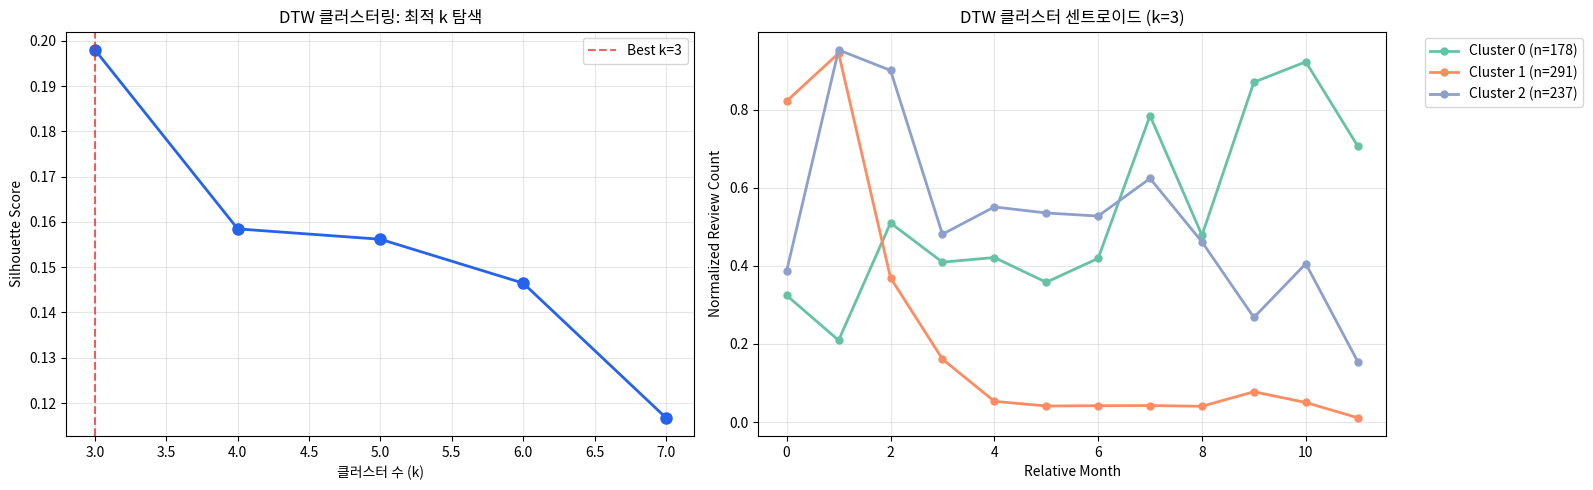

In [304]:
# DTW 클러스터링 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# (1) Silhouette Score by k
ax1 = axes[0]
ks = list(sil_scores.keys())
scores = list(sil_scores.values())
ax1.plot(ks, scores, 'o-', color=COLORS['primary'], linewidth=2, markersize=8)
ax1.axvline(best_k, color=COLORS['negative'], linestyle='--', alpha=0.7, label=f'Best k={best_k}')
ax1.set_xlabel('클러스터 수 (k)')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('DTW 클러스터링: 최적 k 탐색')
ax1.legend()
ax1.grid(True, alpha=0.3)

# (2) 클러스터별 센트로이드 궤적
ax2 = axes[1]
centroids = best_model.cluster_centers_
cluster_sizes = pd.Series(best_labels).value_counts().sort_index()
cmap = plt.cm.Set2
for i in range(best_k):
    centroid = centroids[i].ravel()
    n_items = cluster_sizes.get(i, 0)
    ax2.plot(range(MAX_MONTH), centroid, '-o', color=cmap(i),
             linewidth=2, markersize=5,
             label=f'Cluster {i} (n={n_items})')
ax2.set_xlabel('Relative Month')
ax2.set_ylabel('Normalized Review Count')
ax2.set_title(f'DTW 클러스터 센트로이드 (k={best_k})')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '01_dtw_clustering.png'), bbox_inches='tight', dpi=300)
plt.show()


In [305]:
# 클러스터 자동 라벨링

centroids = best_model.cluster_centers_
cluster_info = []

for i in range(best_k):
    c = centroids[i].ravel()
    early = c[:3].mean()       # Early (0~2개월)
    mid = c[3:6].mean()        # Mid (3~5개월)
    late = c[6:].mean()        # Late (6~11개월)

    # OLS 기울기
    slope = np.polyfit(range(len(c)), c, 1)[0]

    # 후반부 유지율 (late / early)
    retention = late / max(early, 0.01)

    # 자동 라벨링 로직 (보수적 기준)
    if slope < -0.03 and retention < 0.3:
        label = '급락형'
        is_soft_landing = False
    elif slope < -0.01 and retention < 0.6:
        label = '점진하락형'
        is_soft_landing = False
    elif retention >= 0.6 and abs(slope) < 0.02:
        label = '안정유지형'
        is_soft_landing = True
    elif late > mid and slope > 0:
        label = '후기상승형'
        is_soft_landing = True
    elif retention >= 0.6:
        label = '완만유지형'
        is_soft_landing = True
    else:
        label = '기타'
        is_soft_landing = False

    n_items = (best_labels == i).sum()
    cluster_info.append({
        'cluster': i,
        'label': label,
        'is_soft_landing_dtw': is_soft_landing,
        'n_products': n_items,
        'early_mean': early,
        'mid_mean': mid,
        'late_mean': late,
        'slope': slope,
        'retention': retention
    })

cluster_label_df = pd.DataFrame(cluster_info)
print("DTW 클러스터 자동 라벨링 결과:")
print(cluster_label_df[['cluster', 'label', 'is_soft_landing_dtw', 'n_products', 'slope', 'retention']].to_string(index=False))

# cluster_df에 라벨 병합
label_map = dict(zip(cluster_label_df['cluster'], cluster_label_df['label']))
sl_map = dict(zip(cluster_label_df['cluster'], cluster_label_df['is_soft_landing_dtw']))
cluster_df['dtw_label'] = cluster_df['dtw_cluster'].map(label_map)
cluster_df['is_soft_landing_dtw'] = cluster_df['dtw_cluster'].map(sl_map)

print(f"\n DTW 기반 연착륙 상품: {cluster_df['is_soft_landing_dtw'].sum()}개 / {len(cluster_df)}개")

DTW 클러스터 자동 라벨링 결과:
 cluster label  is_soft_landing_dtw  n_products     slope  retention
       0 후기상승형                 True         178  0.051181   2.003328
       1   급락형                False         291 -0.068667   0.061905
       2 점진하락형                False         237 -0.041234   0.544808

 DTW 기반 연착륙 상품: 178개 / 706개


---
## 4. 생존분석

### 방법론
- **사망 이벤트 정의:** 피크 리뷰 수 대비 30% 이하로 2개월 연속 하회 시 '사망'
- **품절 구간 제외:** 연속 0-리뷰 구간은 품절로 간주, 사망 판단에서 제외
- **중도절단(Censoring):** 관측 종료 시점까지 살아있으면 censored
- **Kaplan-Meier:** 비모수적 생존 함수 추정 (전체, 카테고리별, 가격대별)
- **Cox PH 모델:** ABSA 감성 지표 + 상품 특성을 공변량으로 한 반모수적 위험률 모델

### 연착륙 기준 (생존분석)
- **생존 시간(median survival) > 전체 중앙값** 이거나
- **관측 기간 끝까지 생존(censored)** 한 상품

In [306]:
# 4. 생존분석: 사망 이벤트 구성

def build_survival_data(ts_df):
    survival_records = []

    for pc, group in ts_df.groupby('product_code'):
        group = group.sort_values('relative_month')
        counts = group['review_count'].values
        stockouts = group['is_stockout'].values

        if len(counts) == 0:
            continue

        peak = counts.max()
        if peak == 0:
            continue

        threshold = peak * DEATH_THRESHOLD

        # 사망 판단 (품절 구간 제외)
        death_month = None
        consecutive_below = 0

        peak_month = np.argmax(counts)
        for m in range(peak_month + 1, len(counts)):
            if stockouts[m]:
                consecutive_below = 0
                continue
            if counts[m] <= threshold:
                consecutive_below += 1
                if consecutive_below >= DEATH_CONSECUTIVE:
                    death_month = m - DEATH_CONSECUTIVE + 1
                    break
            else:
                consecutive_below = 0

        max_month = group['relative_month'].max()

        if death_month is not None:
            duration = death_month
            event = 1  # 사망
        else:
            duration = max_month + 1
            event = 0  # 중도절단 (생존)

        survival_records.append({
            'product_code': pc,
            'duration': duration,
            'event': event,
            'peak_month': peak_month,
            'peak_count': peak,
            'total_reviews': counts.sum(),
            'n_stockout_months': stockouts.sum()
        })

    return pd.DataFrame(survival_records)

surv_df = build_survival_data(ts_df)

# 상품 메타 정보 조인
surv_df = surv_df.merge(
    products[['product_code', 'price', 'category_1', 'category_2', 'brand_name']].drop_duplicates(),
    on='product_code', how='left'
)

# 가격대 구분
surv_df['price_tier'] = pd.cut(
    surv_df['price'], bins=[0, 2000, 3000, 5000, 10000],
    labels=['~2천', '2~3천', '3~5천', '5천+']
)

print(f" 생존 데이터 구성 완료: {len(surv_df)}개 상품")
print(f"  사망: {surv_df['event'].sum()}개 ({surv_df['event'].mean():.1%})")
print(f"  생존(중도절단): {(surv_df['event']==0).sum()}개")
print(f"\n생존 시간 분포:")
print(surv_df['duration'].describe())

 생존 데이터 구성 완료: 706개 상품
  사망: 343개 (48.6%)
  생존(중도절단): 363개

생존 시간 분포:
count    706.000000
mean       7.389518
std        4.064355
min        1.000000
25%        3.000000
50%        7.000000
75%       12.000000
max       12.000000
Name: duration, dtype: float64


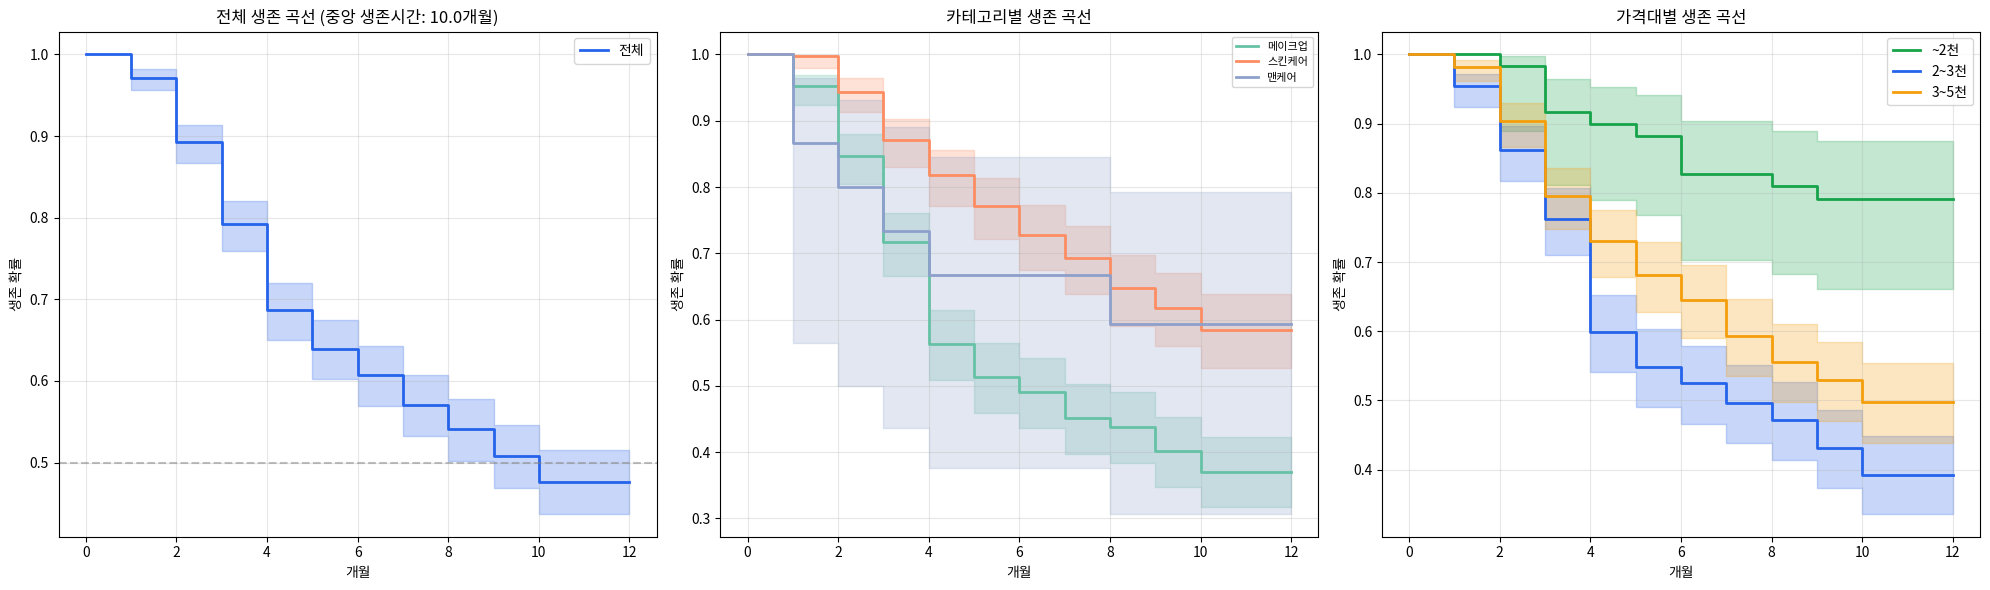


전체 중앙 생존시간: 10.0개월


In [307]:
# Kaplan-Meier 생존 함수 추정

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (1) 전체 생존 곡선
ax1 = axes[0]
kmf = KaplanMeierFitter()
kmf.fit(surv_df['duration'], event_observed=surv_df['event'], label='전체')
kmf.plot_survival_function(ax=ax1, color=COLORS['primary'], linewidth=2)
median_surv = kmf.median_survival_time_
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_title(f'전체 생존 곡선 (중앙 생존시간: {median_surv:.1f}개월)')
ax1.set_xlabel('개월')
ax1.set_ylabel('생존 확률')
ax1.grid(True, alpha=0.3)

# (2) 카테고리별
ax2 = axes[1]
top_cats = surv_df['category_1'].value_counts().head(5).index
cmap = plt.cm.Set2
for idx, cat in enumerate(top_cats):
    sub = surv_df[surv_df['category_1'] == cat]
    if len(sub) < 10:
        continue
    kmf_cat = KaplanMeierFitter()
    kmf_cat.fit(sub['duration'], event_observed=sub['event'], label=cat[:10])
    kmf_cat.plot_survival_function(ax=ax2, color=cmap(idx), linewidth=2)
ax2.set_title('카테고리별 생존 곡선')
ax2.set_xlabel('개월')
ax2.set_ylabel('생존 확률')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# (3) 가격대별
ax3 = axes[2]
colors_price = [COLORS['positive'], COLORS['primary'], COLORS['neutral'], COLORS['negative']]
for idx, tier in enumerate(surv_df['price_tier'].cat.categories):
    sub = surv_df[surv_df['price_tier'] == tier]
    if len(sub) < 10:
        continue
    kmf_p = KaplanMeierFitter()
    kmf_p.fit(sub['duration'], event_observed=sub['event'], label=tier)
    kmf_p.plot_survival_function(ax=ax3, color=colors_price[idx], linewidth=2)
ax3.set_title('가격대별 생존 곡선')
ax3.set_xlabel('개월')
ax3.set_ylabel('생존 확률')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_survival_curves.png'), bbox_inches='tight', dpi=300)
plt.show()

MEDIAN_SURVIVAL = median_surv
print(f"\n전체 중앙 생존시간: {MEDIAN_SURVIVAL:.1f}개월")


Cox PH 피처 후보: 31개
  ['n_reviews', 'overall_pos_rate', 'overall_neu_rate', 'overall_neg_rate', 'mention_rate_가격/가성비', 'mention_rate_디자인', 'mention_rate_배송/포장', 'mention_rate_사용감/성능', 'mention_rate_색상/발색', 'mention_rate_용량/휴대']
  상수 컬럼 제거: ['uncategorized_rate']

Cox PH 모델 적합 완료
  Concordance Index: 0.7681

유의미한 공변량 (p < 0.05): 5개
                          coef     exp(coef)             p
covariate                                                 
overall_pos_rate     -2.561249      0.077208  4.338552e-02
mention_rate_사용감/성능   3.117253     22.584262  2.007331e-04
overall_neg_rate      4.464706     86.895500  1.475609e-02
mention_rate_용량/휴대    5.296072    199.551395  3.900808e-03
mention_rate_디자인     10.551180  38222.501670  3.316335e-11


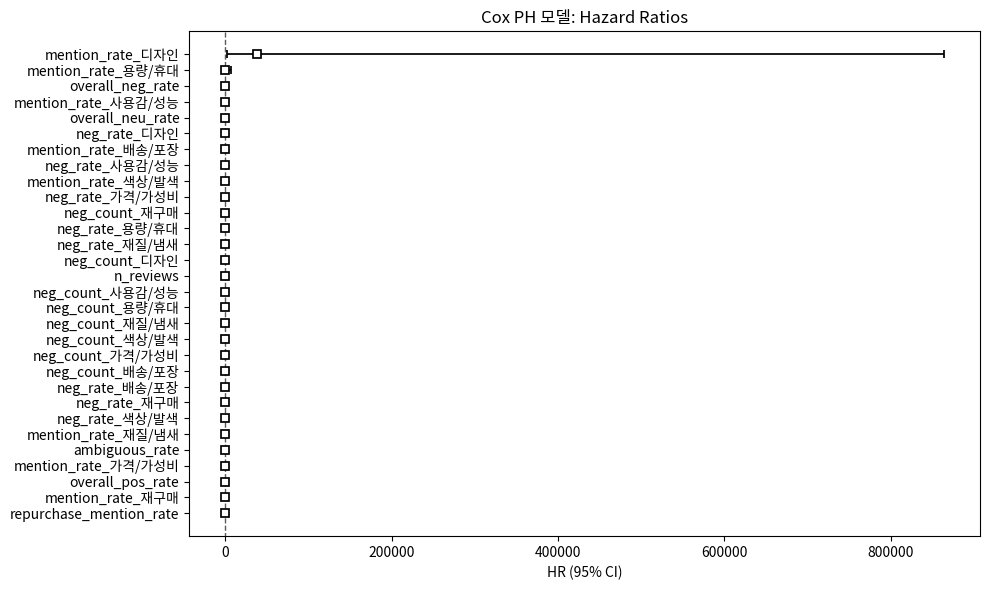

In [308]:
# Cox PH 모델 (공변량: ABSA + 상품 특성)

# surv_df와 겹치는 컬럼 제거 후 merge (price, brand_name, category 등)
surv_existing_cols = set(surv_df.columns) - {'product_code'}
absa_only_cols = [c for c in absa_product.columns if c == 'product_code' or c not in surv_existing_cols]
cox_df = surv_df.merge(absa_product[absa_only_cols], on='product_code', how='left')

# 수치형 ABSA 피처만 선택 (product_code, product_name 등 제외)
non_feature = {'product_code', 'product_name', 'brand_id'}
absa_num_cols = [c for c in absa_only_cols
                 if c not in non_feature and c in cox_df.columns
                 and cox_df[c].dtype in ['float64', 'int64']]

feature_cols = []
for c in absa_num_cols:
    missing_rate = cox_df[c].isna().mean()
    if missing_rate < 0.5:
        feature_cols.append(c)

print(f"Cox PH 피처 후보: {len(feature_cols)}개")
print(f"  {feature_cols[:10]}")

# 결측치 중앙값 대체
cox_data = cox_df[['duration', 'event'] + feature_cols].copy()
cox_data[feature_cols] = cox_data[feature_cols].fillna(cox_data[feature_cols].median())

# 상수 컬럼 제거
constant_cols = [c for c in feature_cols if cox_data[c].nunique() <= 1]
if constant_cols:
    print(f"  상수 컬럼 제거: {constant_cols}")
    feature_cols = [c for c in feature_cols if c not in constant_cols]
    cox_data = cox_data[['duration', 'event'] + feature_cols]

# Cox PH 피팅
cph = CoxPHFitter(penalizer=0.1)
try:
    cph.fit(cox_data, duration_col='duration', event_col='event')

    print(f"\nCox PH 모델 적합 완료")
    print(f"  Concordance Index: {cph.concordance_index_:.4f}")

    summary = cph.summary
    sig = summary[summary['p'] < 0.05].sort_values('coef')
    print(f"\n유의미한 공변량 (p < 0.05): {len(sig)}개")
    if len(sig) > 0:
        print(sig[['coef', 'exp(coef)', 'p']].head(10).to_string())

    fig, ax = plt.subplots(figsize=(10, max(6, len(sig)*0.4)))
    cph.plot(ax=ax, hazard_ratios=True)
    ax.set_title('Cox PH 모델: Hazard Ratios')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, '03_cox_hazard_ratios.png'), bbox_inches='tight', dpi=300)
    plt.show()
except Exception as e:
    print(f"Cox PH 피팅 실패: {e}")
    print("  → 피처 수를 줄여 재시도합니다.")
    top5 = feature_cols[:5]
    cox_data_small = cox_data[['duration', 'event'] + top5]
    cph = CoxPHFitter(penalizer=0.5)
    cph.fit(cox_data_small, duration_col='duration', event_col='event')
    print(f"  Concordance Index: {cph.concordance_index_:.4f}")


In [309]:
# 생존분석 기반 연착륙 라벨 (기준: duration이 SURVIVAL_QUANTILE 분위 초과 또는 censored)

survival_threshold = surv_df['duration'].quantile(SURVIVAL_QUANTILE)
surv_df['is_soft_landing_surv'] = (
    (surv_df['duration'] > survival_threshold) | (surv_df['event'] == 0)
)

print(f" 생존분석 기준: duration > {survival_threshold:.1f}개월 (상위 {100*(1-SURVIVAL_QUANTILE):.0f}%) 또는 censored")
print(f" 생존분석 기반 연착륙 상품: {surv_df['is_soft_landing_surv'].sum()}개 / {len(surv_df)}개")
print(f"  비율: {surv_df['is_soft_landing_surv'].mean():.1%}")

 생존분석 기준: duration > 12.0개월 (상위 25%) 또는 censored
 생존분석 기반 연착륙 상품: 363개 / 706개
  비율: 51.4%


---
## 5. 검색트렌드 통합

### 피처 설계
1. **검색-리뷰 괴리도 :** 검색량과 리뷰 궤적의 상관 및 기울기 차이 → 괴리가 클수록 외부 관심 vs 실제 구매 간 갭
2. **수명주기 분류 :** 검색 패턴 기반 (viral / stable / seasonal / declining)
3. **검색 모멘텀:** 최근 3개월 대비 이전 기간 검색량 증감률
4. **연령대 다양성:** 특정 연령대 편중 vs 고른 분포 → 다양할수록 안정적

In [310]:
# 5. 검색트렌드 피처 엔지니어링

print(" 검색트렌드(브랜드) 컬럼:", search_brand.columns.tolist()[:15])
print(f"  행: {len(search_brand)}, 브랜드 수: {search_brand['keyword_group'].nunique() if 'keyword_group' in search_brand.columns else 'N/A'}")

# 날짜형 컬럼 탐지 (Wide format 대응)
date_like_cols = [c for c in search_brand.columns if '202' in str(c)]

if len(date_like_cols) > 0:
    brand_col = [c for c in search_brand.columns if 'brand' in c.lower() or 'keyword' in c.lower()][0]

    search_features_list = []
    for _, row in search_brand.iterrows():
        brand = row[brand_col]
        values = row[date_like_cols].values.astype(float)
        values = values[~np.isnan(values)]

        if len(values) < 4:
            continue

        # (1) 기울기
        slope = np.polyfit(range(len(values)), values, 1)[0] if len(values) > 1 else 0

        # (2) 모멘텀
        recent = values[-3:].mean() if len(values) >= 3 else values.mean()
        earlier = values[:-3].mean() if len(values) > 3 else values.mean()
        momentum = (recent - earlier) / max(earlier, 1)

        # (3) 변동계수
        cv = values.std() / max(values.mean(), 1)

        # (4) 수명주기 분류
        if len(values) >= 6:
            peak_idx = np.argmax(values)
            peak_ratio = peak_idx / len(values)

            if values.max() > values.mean() * 3 and peak_ratio < 0.3:
                lifecycle = 'viral'
            elif cv < 0.3:
                lifecycle = 'stable'
            elif slope < -0.5:
                lifecycle = 'declining'
            else:
                lifecycle = 'moderate'
        else:
            lifecycle = 'unknown'

        search_features_list.append({
            'brand_name': brand,
            'search_slope': slope,
            'search_momentum': momentum,
            'search_cv': cv,
            'search_lifecycle': lifecycle,
            'search_mean': values.mean(),
            'search_max': values.max(),
        })

    search_feat_df = pd.DataFrame(search_features_list)
    print(f"\n 검색트렌드 피처 구성: {len(search_feat_df)}개 브랜드")
    print(f"  수명주기 분포:\n{search_feat_df['search_lifecycle'].value_counts()}")
else:
    print("  Long format 감지 -> Pivot 처리")
    if 'keyword_group' in search_brand.columns and 'period' in search_brand.columns and 'ratio' in search_brand.columns:
        search_pivot = search_brand.pivot_table(
            index='keyword_group', 
            columns='period', 
            values='ratio'
        ).reset_index()
        
        brand_col = 'keyword_group'
        date_cols = [c for c in search_pivot.columns if c != 'keyword_group']
        
        search_features_list = []
        for _, row in search_pivot.iterrows():
            brand = row[brand_col]
            values = row[date_cols].values.astype(float)
            values = values[~np.isnan(values)]
            
            if len(values) < 4: continue
            
            slope = np.polyfit(range(len(values)), values, 1)[0]
            recent = values[-3:].mean() if len(values) >= 3 else values.mean()
            earlier = values[:-3].mean() if len(values) > 3 else values.mean()
            momentum = (recent - earlier) / max(earlier, 1)
            cv = values.std() / max(values.mean(), 1)
            
            search_features_list.append({
                'brand_name': brand,
                'search_slope': slope,
                'search_momentum': momentum,
                'search_cv': cv,
                'search_mean': values.mean(),
                'search_max': values.max()
            })
        
        search_feat_df = pd.DataFrame(search_features_list)
        print(f"  Long format 피봇팅 완료: {len(search_feat_df)}개 브랜드")
    else:
        search_feat_df = pd.DataFrame()
        print("  필요한 컬럼(keyword_group, period, ratio)이 없어 처리에 실패했습니다.")



 검색트렌드(브랜드) 컬럼: ['keyword_group', 'period', 'ratio', 'round', 'segment_type', 'segment_label']
  행: 738, 브랜드 수: 8
  Long format 감지 -> Pivot 처리
  Long format 피봇팅 완료: 7개 브랜드


In [311]:
# 연령대 다양성 (세그먼트 데이터)
age_col_candidates = [c for c in search_segment.columns if 'age' in c.lower()]
if len(age_col_candidates) > 0:
    age_col = age_col_candidates[0]
    brand_col_seg = [c for c in search_segment.columns if 'brand' in c.lower()][0]
    value_col = [c for c in search_segment.columns if 'value' in c.lower() or 'ratio' in c.lower() or 'count' in c.lower()]

    if len(value_col) > 0:
        val_c = value_col[0]
        age_diversity = (
            search_segment
            .groupby(brand_col_seg)
            .apply(lambda g: g.groupby(age_col)[val_c].sum().pipe(
                lambda s: 1 - (s / s.sum()).pow(2).sum()
            ))
            .reset_index()
        )
        age_diversity.columns = ['brand_name', 'age_diversity']
        search_feat_df = search_feat_df.merge(age_diversity, on='brand_name', how='left')
        print(f"  연령대 다양성 추가: {age_diversity['age_diversity'].describe()}")
    else:
        print("  연령대 값 컬럼을 찾을 수 없음")
else:
    print("  세그먼트 데이터에 연령 컬럼 없음")

  세그먼트 데이터에 연령 컬럼 없음


In [312]:
# 검색-리뷰 괴리도 (Divergence)

product_brand = products[['product_code', 'brand_name']].drop_duplicates()

brand_monthly = (
    reviews
    .merge(product_brand, on='product_code', how='left')
    .groupby(['brand_name', 'review_month'])
    .size()
    .reset_index(name='review_count')
    .sort_values(['brand_name', 'review_month'])
)

if len(search_feat_df) > 0 and 'search_slope' in search_feat_df.columns:
    brand_review_slope = (
        brand_monthly
        .groupby('brand_name')
        .apply(lambda g: np.polyfit(range(len(g)), g['review_count'].values, 1)[0] if len(g) > 1 else 0)
        .reset_index(name='review_slope')
    )

    divergence = search_feat_df[['brand_name', 'search_slope']].merge(
        brand_review_slope, on='brand_name', how='inner'
    )

    from sklearn.preprocessing import MinMaxScaler
    for col in ['search_slope', 'review_slope']:
        scaler = MinMaxScaler()
        divergence[col + '_norm'] = scaler.fit_transform(divergence[[col]])

    divergence['search_review_divergence'] = abs(
        divergence['search_slope_norm'] - divergence['review_slope_norm']
    )

    search_feat_df = search_feat_df.merge(
        divergence[['brand_name', 'search_review_divergence']], on='brand_name', how='left'
    )

    print(f" 검색-리뷰 괴리도 계산 완료")
    print(f"  평균 괴리도: {search_feat_df['search_review_divergence'].mean():.3f}")
    top_div = search_feat_df.nlargest(5, 'search_review_divergence')[['brand_name', 'search_review_divergence']]
    print(f"  괴리도 상위 5개 브랜드:")
    print(top_div.to_string(index=False))
else:
    print("검색트렌드 피처가 없어 괴리도를 계산하지 못했습니다.")

 검색-리뷰 괴리도 계산 완료
  평균 괴리도: 0.091
  괴리도 상위 5개 브랜드:
brand_name  search_review_divergence
    김정문알로에                  0.236043
     그로우어스                  0.137732
       바세린                  0.112297
       손앤박                  0.077698
 더랩 바이 블랑두                  0.075646


---
## 6. ML 통합 모델 (LightGBM)

### Pseudo Label 생성
- **DTW 클러스터링** → 안정유지형/후기상승형 = positive
- **생존분석** → 생존시간 > 중앙값 or censored = positive
- **규칙 기반(SLI-like)** → 3구간 유지율 + 기울기 조건 = positive
- **Multi-rule Ensemble:** 3개 방법 **만장일치(3/3)** → positive pseudo label

### 피처 엔지니어링
1. **시계열 피처:** 3구간 평균, 기울기, 변동성, 피크 위치, Changepoint 수
2. **상품 피처:** 가격, 가격대, 카테고리, 리뷰 밀도, engagement_score
3. **ABSA 피처:** aspect별 감성 비율, 언급률, 전체 긍정/부정 비율
4. **사용자 피처:** 재구매율, VIP 비율, 활동 수준 분포
5. **성분 피처:** 주요 성분 수, 주의 성분 수
6. **검색트렌드 피처:** 기울기, 모멘텀, 변동계수, 수명주기, 연령대 다양성

In [313]:
# 6. ML 모델: Pseudo Label 생성

def rule_based_soft_landing(ts_df, product_codes):
    results = []
    for pc in product_codes:
        sub = ts_df[ts_df['product_code'] == pc].sort_values('relative_month')
        counts = sub['review_count'].values

        if len(counts) < 6:
            results.append({'product_code': pc, 'is_soft_landing_rule': False})
            continue

        early = counts[:3].mean()
        mid = counts[3:6].mean()
        late = counts[6:].mean() if len(counts) > 6 else counts[3:].mean()

        if early == 0:
            retention_ok = False
        else:
            retention_ok = (late / early >= RETENTION_LATE_RATIO) and (mid / early >= RETENTION_MID_RATIO)

        slope = np.polyfit(range(len(counts)), counts, 1)[0]
        slope_ok = slope > SLOPE_MIN

        results.append({
            'product_code': pc,
            'is_soft_landing_rule': retention_ok and slope_ok
        })

    return pd.DataFrame(results)

valid_pcs = cluster_df['product_code'].tolist()
rule_df = rule_based_soft_landing(ts_df, valid_pcs)

# 3개 방법 통합
pseudo_df = cluster_df[['product_code', 'is_soft_landing_dtw']].merge(
    surv_df[['product_code', 'is_soft_landing_surv']], on='product_code', how='left'
).merge(
    rule_df, on='product_code', how='left'
)

for col in ['is_soft_landing_dtw', 'is_soft_landing_surv', 'is_soft_landing_rule']:
    pseudo_df[col] = pseudo_df[col].fillna(False)

pseudo_df['vote_count'] = (
    pseudo_df['is_soft_landing_dtw'].astype(int) +
    pseudo_df['is_soft_landing_surv'].astype(int) +
    pseudo_df['is_soft_landing_rule'].astype(int)
)
pseudo_df['pseudo_label'] = (pseudo_df['vote_count'] >= 3).astype(int)  # 만장일치(3/3)만 합격

print(f" Pseudo Label 생성 완료: {len(pseudo_df)}개 상품")
print(f"\n방법별 연착륙 판정:")
print(f"  DTW: {pseudo_df['is_soft_landing_dtw'].sum()}")
print(f"  생존분석: {pseudo_df['is_soft_landing_surv'].sum()}")
print(f"  규칙기반: {pseudo_df['is_soft_landing_rule'].sum()}")
print(f"\n투표 분포:")
print(pseudo_df['vote_count'].value_counts().sort_index())
print(f"\n최종 Pseudo Label (만장일치 3/3): {pseudo_df['pseudo_label'].sum()} ({pseudo_df['pseudo_label'].mean():.1%})")

 Pseudo Label 생성 완료: 706개 상품

방법별 연착륙 판정:
  DTW: 178
  생존분석: 363
  규칙기반: 218

투표 분포:
vote_count
0    326
1    153
2     75
3    152
Name: count, dtype: int64

최종 Pseudo Label (만장일치 3/3): 152 (21.5%)


In [314]:
# 피처 엔지니어링

# --- (1) 시계열 피처 ---
def extract_ts_features(ts_df, product_codes):
    features = []
    for pc in product_codes:
        sub = ts_df[ts_df['product_code'] == pc].sort_values('relative_month')
        counts = sub['review_count'].values

        if len(counts) == 0:
            continue

        early = counts[:3].mean()
        mid = counts[3:6].mean() if len(counts) > 3 else 0
        late = counts[6:].mean() if len(counts) > 6 else 0

        slope = np.polyfit(range(len(counts)), counts, 1)[0] if len(counts) > 1 else 0

        if len(counts) > 1:
            trend = np.polyval(np.polyfit(range(len(counts)), counts, 1), range(len(counts)))
            residual_std = np.std(counts - trend)
        else:
            residual_std = 0

        peak_idx = np.argmax(counts)
        peak_ratio = peak_idx / max(len(counts) - 1, 1)

        try:
            algo = rpt.Pelt(model="rbf", min_size=2).fit(counts.reshape(-1, 1))
            cps = algo.predict(pen=3)
            n_changepoints = len(cps) - 1
        except:
            n_changepoints = 0

        retention_mid = mid / max(early, 0.01)
        retention_late = late / max(early, 0.01)
        stockout_rate = sub['is_stockout'].mean()

        features.append({
            'product_code': pc,
            'ts_early_mean': early,
            'ts_mid_mean': mid,
            'ts_late_mean': late,
            'ts_slope': slope,
            'ts_residual_std': residual_std,
            'ts_peak_ratio': peak_ratio,
            'ts_peak_count': counts.max(),
            'ts_total': counts.sum(),
            'ts_cv': counts.std() / max(counts.mean(), 0.01),
            'ts_n_changepoints': n_changepoints,
            'ts_retention_mid': retention_mid,
            'ts_retention_late': retention_late,
            'ts_stockout_rate': stockout_rate,
            'ts_n_months': len(counts),
        })

    return pd.DataFrame(features)

ts_feat = extract_ts_features(ts_df, valid_pcs)



In [315]:
# --- (2) 상품 피처 ---
product_feat = products[['product_code', 'price', 'category_1']].drop_duplicates()
product_feat['price_log'] = np.log1p(product_feat['price'])
cat_dummies = pd.get_dummies(product_feat['category_1'], prefix='cat')
product_feat = pd.concat([product_feat, cat_dummies], axis=1)

# --- (3) ABSA 피처 (중복 컬럼 제거) ---
# absa_product에서 products와 겹치는 메타 컬럼 제거
absa_meta_cols = ['brand_id', 'product_name', 'price', 'brand_name', 'category_1', 'category_2']
absa_feat = absa_product.drop(columns=[c for c in absa_meta_cols if c in absa_product.columns], errors='ignore')

# --- (4) 사용자 행동 피처 ---
user_feat = reviews.groupby('product_code').agg(
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std'),
    n_unique_users=('user_id', 'nunique'),
).reset_index()
user_feat['rating_std'] = user_feat['rating_std'].fillna(0)

if 'is_reorder' in reviews.columns:
    reorder_feat = reviews.groupby('product_code')['is_reorder'].mean().reset_index(name='reorder_rate')
    user_feat = user_feat.merge(reorder_feat, on='product_code', how='left')



In [316]:
# --- (5) 성분 피처 ---
if 'is_caution' in ingredients.columns:
    ingr_feat = ingredients.groupby('product_code').agg(
        n_ingredients=('product_code', 'size'),
        n_caution=('is_caution', 'sum'),
    ).reset_index()
else:
    ingr_feat = ingredients.groupby('product_code').size().reset_index(name='n_ingredients')



In [317]:
# --- (6) 검색트렌드 피처 ---
product_brand = products[['product_code', 'brand_name']].drop_duplicates()

if len(search_feat_df) > 0:
    search_feat_product = product_brand.merge(search_feat_df, on='brand_name', how='left')
    search_feat_product = search_feat_product.drop(columns=['brand_name'])
    if 'search_lifecycle' in search_feat_product.columns:
        lc_dummies = pd.get_dummies(search_feat_product['search_lifecycle'], prefix='search_lc')
        search_feat_product = pd.concat([search_feat_product, lc_dummies], axis=1)
        search_feat_product = search_feat_product.drop(columns=['search_lifecycle'])
else:
    search_feat_product = product_brand[['product_code']].copy()

# === 전체 피처 병합 (suffixes로 중복 방지) ===
feature_df = ts_feat.copy()
for df in [product_feat.drop(columns=['category_1'], errors='ignore'),
           absa_feat, user_feat, ingr_feat, search_feat_product]:
    # 이미 있는 컬럼은 제거 (product_code 제외)
    existing = set(feature_df.columns) - {'product_code'}
    new_cols = [c for c in df.columns if c not in existing or c == 'product_code']
    if 'product_code' in new_cols:
        feature_df = feature_df.merge(df[new_cols], on='product_code', how='left')
    else:
        print(f"  product_code 없는 df 스킵")

feature_df = feature_df.merge(pseudo_df[['product_code', 'pseudo_label']], on='product_code', how='inner')

exclude_cols = ['product_code', 'pseudo_label', 'brand_name', 'category_1', 'category_2', 'name', 'product_name']
feature_cols_ml = [c for c in feature_df.columns
                   if c not in exclude_cols
                   and feature_df[c].dtype in ['float64', 'int64', 'bool', 'uint8']
                   and not c.startswith('_')]

feature_df[feature_cols_ml] = feature_df[feature_cols_ml].fillna(0)

print(f"피처 엔지니어링 완료")
print(f"  최종 피처 수: {len(feature_cols_ml)}")
print(f"  상품 수: {len(feature_df)}")
print(f"  Pseudo Label 분포: {feature_df['pseudo_label'].value_counts().to_dict()}")

피처 엔지니어링 완료
  최종 피처 수: 61
  상품 수: 706
  Pseudo Label 분포: {0: 554, 1: 152}


In [318]:
# LightGBM 5-Fold Stratified CV

X = feature_df[feature_cols_ml].values
y = feature_df['pseudo_label'].values
product_codes_ml = feature_df['product_code'].values

params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 6,
    'min_child_samples': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'is_unbalance': True,
    'random_state': RANDOM_STATE,
    'verbose': -1,
    'n_estimators': 300,
    'early_stopping_rounds': 30,
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probs = np.zeros(len(y))
fold_metrics = []
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
    )

    val_probs = model.predict_proba(X_val)[:, 1]
    oof_probs[val_idx] = val_probs

    val_preds = (val_probs >= 0.5).astype(int)
    f1 = f1_score(y_val, val_preds)
    auc = roc_auc_score(y_val, val_probs)

    fold_metrics.append({'fold': fold + 1, 'f1': f1, 'auc': auc})
    models.append(model)
    print(f"  Fold {fold+1}: F1={f1:.4f}, AUC={auc:.4f}")

oof_preds = (oof_probs >= 0.5).astype(int)
overall_f1 = f1_score(y, oof_preds)
overall_auc = roc_auc_score(y, oof_probs)

print(f"\n{'='*50}")
print(f"OOF 전체 성능")
print(f"  F1 Score: {overall_f1:.4f}")
print(f"  ROC-AUC: {overall_auc:.4f}")
print(f"{'='*50}")
print(f"\n{classification_report(y, oof_preds, target_names=['Non-SL', 'Soft Landing'])}")

feature_df['ml_prob'] = oof_probs
feature_df['ml_pred'] = oof_preds

  Fold 1: F1=0.8571, AUC=0.9776
  Fold 2: F1=0.9538, AUC=0.9982
  Fold 3: F1=0.9032, AUC=0.9886
  Fold 4: F1=0.8571, AUC=0.9751
  Fold 5: F1=0.9375, AUC=0.9958

OOF 전체 성능
  F1 Score: 0.9012
  ROC-AUC: 0.9879

              precision    recall  f1-score   support

      Non-SL       0.99      0.95      0.97       554
Soft Landing       0.85      0.96      0.90       152

    accuracy                           0.95       706
   macro avg       0.92      0.96      0.94       706
weighted avg       0.96      0.95      0.96       706



In [319]:
# SHAP Feature Importance

explainer = shap.TreeExplainer(models[-1])
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

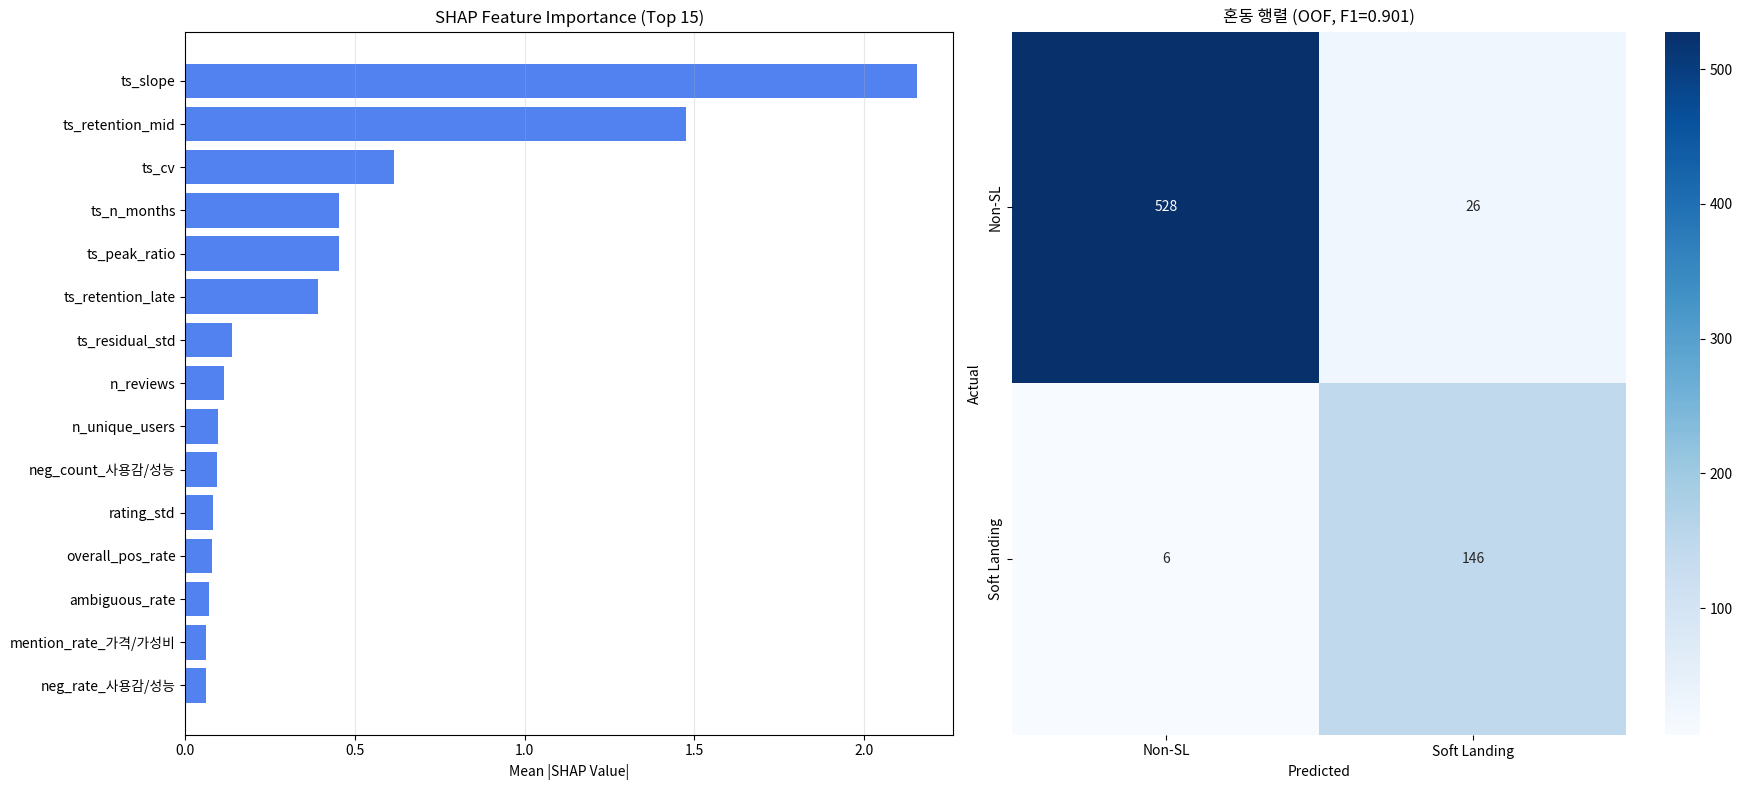

In [320]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# (1) SHAP Summary Plot (bar)
ax1 = axes[0]
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
top_idx = np.argsort(mean_abs_shap)[-15:]
feature_names = [feature_cols_ml[i] for i in top_idx]
values = mean_abs_shap[top_idx]

ax1.barh(range(len(feature_names)), values, color=COLORS['primary'], alpha=0.8)
ax1.set_yticks(range(len(feature_names)))
ax1.set_yticklabels(feature_names)
ax1.set_xlabel('Mean |SHAP Value|')
ax1.set_title('SHAP Feature Importance (Top 15)')
ax1.grid(True, alpha=0.3, axis='x')

# (2) 혼동 행렬
ax2 = axes[1]
cm = confusion_matrix(y, oof_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Non-SL', 'Soft Landing'],
            yticklabels=['Non-SL', 'Soft Landing'])
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title(f'혼동 행렬 (OOF, F1={overall_f1:.3f})')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '04_ml_confusion_matrix.png'), bbox_inches='tight', dpi=300)
plt.show()


In [321]:
print("SHAP 기반 Top 15 피처:")
for i, (name, val) in enumerate(zip(reversed(feature_names), reversed(values))):
    print(f"  {i+1:2d}. {name:30s} {val:.4f}")

SHAP 기반 Top 15 피처:
   1. ts_slope                       2.1546
   2. ts_retention_mid               1.4740
   3. ts_cv                          0.6135
   4. ts_n_months                    0.4533
   5. ts_peak_ratio                  0.4523
   6. ts_retention_late              0.3897
   7. ts_residual_std                0.1366
   8. n_reviews                      0.1135
   9. n_unique_users                 0.0955
  10. neg_count_사용감/성능               0.0933
  11. rating_std                     0.0823
  12. overall_pos_rate               0.0773
  13. ambiguous_rate                 0.0687
  14. mention_rate_가격/가성비            0.0599
  15. neg_rate_사용감/성능                0.0595


---
## 7. 교차 검증 & 최종 연착륙 리스트

### 교차 검증 방법
- **4가지 방법론** 비교: DTW, 생존분석, 규칙기반, ML(LightGBM)
- **합의 매트릭스:** 각 방법 간 일치율
- **최종 판정:** 4개 중 **만장일치(4/4)** = 고신뢰(High Confidence) 연착륙

In [322]:
# 7. 교차 검증: 방법론 간 합의

agreement_df = pseudo_df[['product_code', 'is_soft_landing_dtw', 'is_soft_landing_surv', 'is_soft_landing_rule']].merge(
    feature_df[['product_code', 'ml_pred']], on='product_code', how='inner'
)
agreement_df = agreement_df.rename(columns={'ml_pred': 'is_soft_landing_ml'})

methods = ['is_soft_landing_dtw', 'is_soft_landing_surv', 'is_soft_landing_rule', 'is_soft_landing_ml']
method_names = ['DTW', '생존분석', '규칙기반', 'ML(LightGBM)']

print("=" * 60)
print("방법론별 연착륙 판정 요약")
print("=" * 60)
for mname, mcol in zip(method_names, methods):
    n_sl = agreement_df[mcol].sum()
    print(f"  {mname:15s}: {n_sl:4d}개 ({n_sl/len(agreement_df):.1%})")

# 합의 매트릭스
agreement_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
for i, (n1, c1) in enumerate(zip(method_names, methods)):
    for j, (n2, c2) in enumerate(zip(method_names, methods)):
        agree = (agreement_df[c1] == agreement_df[c2]).mean()
        agreement_matrix.loc[n1, n2] = agree


방법론별 연착륙 판정 요약
  DTW            :  178개 (25.2%)
  생존분석           :  363개 (51.4%)
  규칙기반           :  218개 (30.9%)
  ML(LightGBM)   :  172개 (24.4%)



방법론 간 일치율 (Agreement Matrix):


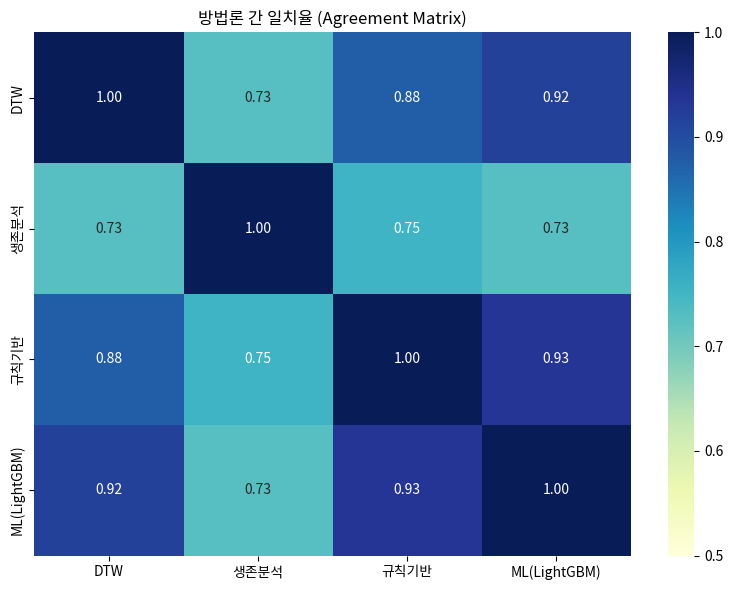

In [323]:
print(f"\n방법론 간 일치율 (Agreement Matrix):")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0.5, vmax=1.0, ax=ax)
ax.set_title('방법론 간 일치율 (Agreement Matrix)')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '05_agreement_matrix.png'), bbox_inches='tight', dpi=300)
plt.show()


In [324]:
# 최종 투표 (FINAL_AGREEMENT_MIN: 4개 방법 중 N개 이상 동의만 연착륙)
agreement_df['total_votes'] = agreement_df[methods].sum(axis=1)
agreement_df['final_soft_landing'] = (agreement_df['total_votes'] >= FINAL_AGREEMENT_MIN).astype(int)
agreement_df['confidence'] = agreement_df['total_votes'].map({
    0: 'Non-SL (확실)', 1: 'Non-SL (약)', 2: 'Non-SL (경계)',
    3: 'SL (3/4 합의)', 4: 'SL (만장일치)'
})

print(f"\n투표 분포:")
print(agreement_df['total_votes'].value_counts().sort_index())
print(f"\n 최종 연착륙 상품 ({FINAL_AGREEMENT_MIN}+ 합의): {agreement_df['final_soft_landing'].sum()}개")
print(f"  [투표 수별] 4표(만장일치): {(agreement_df['total_votes']==4).sum()}개, 3표: {(agreement_df['total_votes']==3).sum()}개, 2표: {(agreement_df['total_votes']==2).sum()}개, 1표: {(agreement_df['total_votes']==1).sum()}개, 0표: {(agreement_df['total_votes']==0).sum()}개")


투표 분포:
total_votes
0    326
1    152
2     51
3     31
4    146
Name: count, dtype: int64

 최종 연착륙 상품 (4+ 합의): 146개
  [투표 수별] 4표(만장일치): 146개, 3표: 31개, 2표: 51개, 1표: 152개, 0표: 326개


In [325]:
# 최종 연착륙 상품 리스트

final_df = agreement_df.merge(
    products[['product_code', 'name', 'brand_name', 'price', 'category_1', 'category_2']].drop_duplicates(),
    on='product_code', how='left'
).merge(
    feature_df[['product_code', 'ml_prob']], on='product_code', how='left'
)

sl_products = final_df[final_df['final_soft_landing'] == 1].sort_values(
    ['total_votes', 'ml_prob'], ascending=[False, False]
)
if MAX_SOFT_LANDING_PRODUCTS is not None and len(sl_products) > MAX_SOFT_LANDING_PRODUCTS:
    sl_products = sl_products.head(MAX_SOFT_LANDING_PRODUCTS)
    print(f"  (3+ 합의 {len(final_df[final_df['final_soft_landing']==1])}개 중 상위 {MAX_SOFT_LANDING_PRODUCTS}개로 제한)")

print(f"{'='*80}")
print(f"최종 연착륙 상품 리스트: {len(sl_products)}개")
print(f"{'='*80}")

print(f"\n카테고리별 분포:")
cat_dist = sl_products['category_1'].value_counts()
for cat, cnt in cat_dist.items():
    print(f"  {cat}: {cnt}개 ({cnt/len(sl_products):.1%})")

print(f"\n가격대별 분포:")
price_dist = pd.cut(sl_products['price'], bins=[0, 2000, 3000, 5000, 10000],
                     labels=['~2천', '2~3천', '3~5천', '5천+']).value_counts()
for tier, cnt in price_dist.items():
    print(f"  {tier}: {cnt}개")

print(f"\n브랜드별 상위 10:")
brand_dist = sl_products['brand_name'].value_counts().head(10)
for brand, cnt in brand_dist.items():
    print(f"  {brand}: {cnt}개")

print(f"\n만장일치 + 고확률 상위 20:")
top20 = sl_products.nlargest(20, 'ml_prob')
display_cols = ['product_code', 'name', 'brand_name', 'price', 'category_1', 'total_votes', 'ml_prob']
print(top20[display_cols].to_string(index=False))

최종 연착륙 상품 리스트: 146개

카테고리별 분포:
  스킨케어: 97개 (66.4%)
  메이크업: 46개 (31.5%)
  맨케어: 3개 (2.1%)

가격대별 분포:
  3~5천: 67개
  2~3천: 51개
  ~2천: 28개
  5천+: 0개

브랜드별 상위 10:
  다이소: 18개
  태그: 16개
  드롭비: 10개
  입큰: 9개
  VT: 7개
  오릭스: 6개
  트윙클팝: 6개
  다나한: 5개
  마데카21: 5개
  비프루브: 5개

만장일치 + 고확률 상위 20:
 product_code                                      name brand_name  price category_1 total_votes  ml_prob
      1040473                              병풀 클렌징티슈 30매        다이소 1000.0       스킨케어           4 0.999241
      1045541                        입큰 퍼스널수분프라이머 25 ml         입큰 3000.0       메이크업           4 0.999075
      1048272                   드롭비 컬러즈 커버픽 컨실러 클리어 베이지        드롭비 3000.0       메이크업           4 0.998935
      1045431                      태그 슬림브로우펜슬(2호_애쉬브라운)         태그 3000.0       메이크업           4 0.998890
      1048273                   드롭비 컬러즈 커버픽 컨실러 내추럴 베이지        드롭비 3000.0       메이크업           4 0.998834
      1045422                  태그 듀얼멀티쉐딩(1호_소프트웜) 9.4 g         태그 5000.0       메이크업 

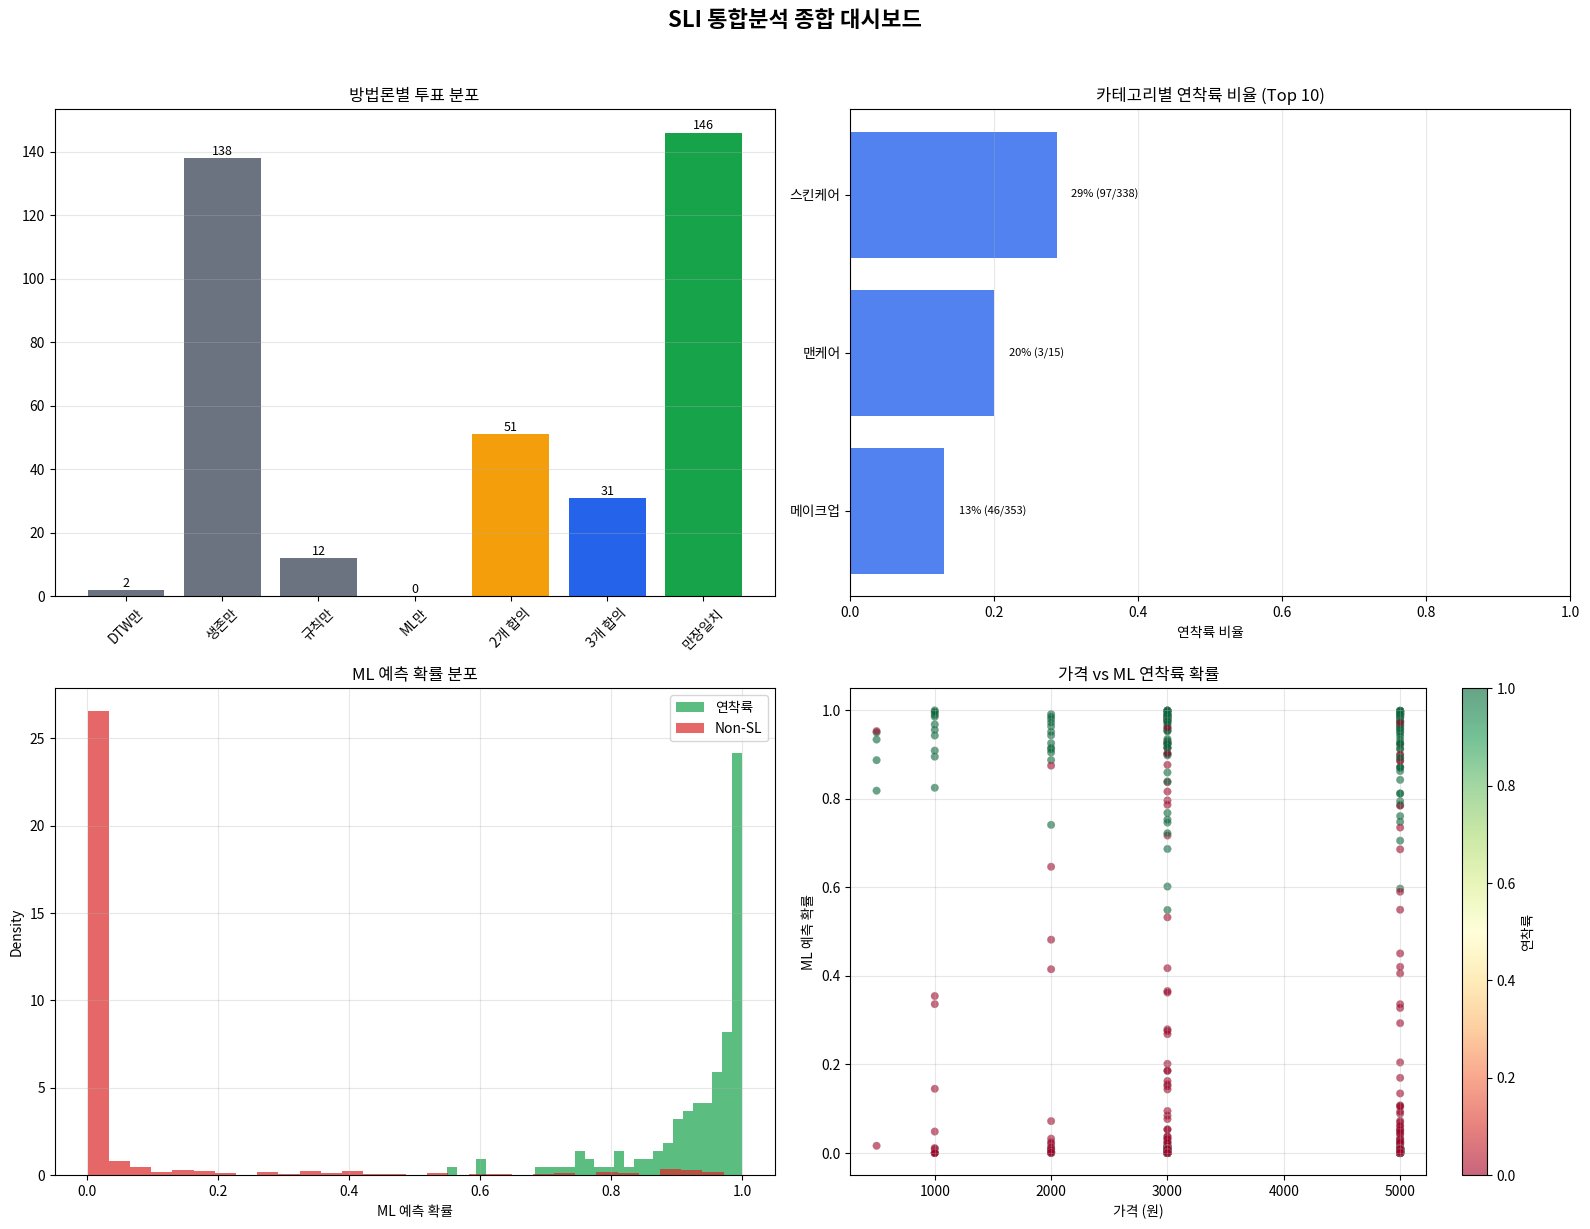

In [326]:
# 종합 시각화 (4-Panel Summary)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) 투표 분포
ax1 = axes[0, 0]
method_counts = {
    'DTW만': ((agreement_df['total_votes'] == 1) & agreement_df['is_soft_landing_dtw']).sum(),
    '생존만': ((agreement_df['total_votes'] == 1) & agreement_df['is_soft_landing_surv']).sum(),
    '규칙만': ((agreement_df['total_votes'] == 1) & agreement_df['is_soft_landing_rule']).sum(),
    'ML만': ((agreement_df['total_votes'] == 1) & agreement_df['is_soft_landing_ml'].astype(bool)).sum(),
    '2개 합의': (agreement_df['total_votes'] == 2).sum(),
    '3개 합의': (agreement_df['total_votes'] == 3).sum(),
    '만장일치': (agreement_df['total_votes'] == 4).sum(),
}
bars = ax1.bar(method_counts.keys(), method_counts.values(),
               color=[COLORS['gray']]*4 + [COLORS['neutral'], COLORS['primary'], COLORS['positive']])
ax1.set_title('방법론별 투표 분포')
ax1.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, method_counts.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')

# (2) 카테고리별 연착륙 비율
ax2 = axes[0, 1]
cat_total = final_df.groupby('category_1')['final_soft_landing'].agg(['sum', 'count'])
cat_total['rate'] = cat_total['sum'] / cat_total['count']
cat_total = cat_total.sort_values('rate', ascending=True).tail(10)
ax2.barh(cat_total.index, cat_total['rate'], color=COLORS['primary'], alpha=0.8)
ax2.set_xlabel('연착륙 비율')
ax2.set_title('카테고리별 연착륙 비율 (Top 10)')
ax2.set_xlim(0, 1)
for i, (idx, row) in enumerate(cat_total.iterrows()):
    ax2.text(row['rate'] + 0.02, i, f"{row['rate']:.0%} ({int(row['sum'])}/{int(row['count'])})", va='center', fontsize=8)
ax2.grid(True, alpha=0.3, axis='x')

# (3) ML 확률 분포
ax3 = axes[1, 0]
sl_mask = final_df['final_soft_landing'] == 1
ax3.hist(final_df.loc[sl_mask, 'ml_prob'], bins=30, alpha=0.7, color=COLORS['positive'], label='연착륙', density=True)
ax3.hist(final_df.loc[~sl_mask, 'ml_prob'], bins=30, alpha=0.7, color=COLORS['negative'], label='Non-SL', density=True)
ax3.set_xlabel('ML 예측 확률')
ax3.set_ylabel('Density')
ax3.set_title('ML 예측 확률 분포')
ax3.legend()
ax3.grid(True, alpha=0.3)

# (4) 가격 vs ML확률
ax4 = axes[1, 1]
scatter = ax4.scatter(
    final_df['price'], final_df['ml_prob'],
    c=final_df['final_soft_landing'], cmap='RdYlGn',
    alpha=0.6, s=30, edgecolors='gray', linewidth=0.3
)
ax4.set_xlabel('가격 (원)')
ax4.set_ylabel('ML 예측 확률')
ax4.set_title('가격 vs ML 연착륙 확률')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='연착륙')

plt.suptitle('SLI 통합분석 종합 대시보드', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '06_final_summary.png'), bbox_inches='tight', dpi=300)
plt.show()


In [327]:
# 결과 저장

import os

OUTPUT_DIR = os.path.join(PROJECT_ROOT, '02_outputs/data/sli')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# (1) 최종 연착륙 리스트
export_cols = [
    'product_code', 'name', 'brand_name', 'price', 'category_1', 'category_2',
    'is_soft_landing_dtw', 'is_soft_landing_surv', 'is_soft_landing_rule', 'is_soft_landing_ml',
    'total_votes', 'final_soft_landing', 'confidence', 'ml_prob'
]
export_df = final_df[[c for c in export_cols if c in final_df.columns]]
export_path = os.path.join(OUTPUT_DIR, 'sli_integrated_results.csv')
export_df.to_csv(export_path, index=False, encoding='utf-8-sig')
print(f" 통합 결과 저장: {export_path}")

# (2) DTW 클러스터 정보
cluster_export = cluster_df.merge(
    products[['product_code', 'name', 'brand_name']].drop_duplicates(),
    on='product_code', how='left'
)
cluster_path = os.path.join(OUTPUT_DIR, 'dtw_clusters.csv')
cluster_export.to_csv(cluster_path, index=False, encoding='utf-8-sig')
print(f" DTW 클러스터 저장: {cluster_path}")

# (3) 피처 중요도
importance_df = pd.DataFrame({
    'feature': feature_cols_ml,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
importance_path = os.path.join(OUTPUT_DIR, 'feature_importance_shap.csv')
importance_df.to_csv(importance_path, index=False, encoding='utf-8-sig')
print(f" 피처 중요도 저장: {importance_path}")

print(f"\n 결과 디렉토리: {OUTPUT_DIR}")

 통합 결과 저장: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/02_outputs/data/sli/sli_integrated_results.csv
 DTW 클러스터 저장: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/02_outputs/data/sli/dtw_clusters.csv
 피처 중요도 저장: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/02_outputs/data/sli/feature_importance_shap.csv

 결과 디렉토리: /Users/yu_seok/Documents/문서 - Mac/workspace/01_현재진행/01_nbCamp/nb_Project/Why-pi/02_outputs/data/sli


---
## 요약 (Summary)

### 방법론 비교

| 방법론 | 접근 | 장점 | 한계 |
|--------|------|------|------|
| **DTW 클러스터링** | 시계열 형태 기반 비지도 분류 | 데이터 주도, 직관적 패턴 | k 선택 주관성 |
| **생존분석** | 사망 이벤트 + 공변량 모델 | 중도절단 처리, 위험인자 해석 | 사망 정의 민감도 |
| **규칙 기반** | 3구간 유지율 + 기울기 | 단순, 해석 용이 | 임계값 주관성 |
| **ML (LightGBM)** | Pseudo label + 다차원 피처 | 비선형 관계 포착, 피처 중요도 | 라벨 의존성 |

### 핵심 인사이트
1. **다중 방법론 만장일치(4/4)** 가 단일 방법론보다 신뢰도가 높음
2. **SHAP 분석**을 통해 연착륙을 결정하는 핵심 요인을 데이터로 증명
3. **검색트렌드**와 **ABSA 감성**이 시계열 패턴만으로는 포착 못하는 추가 정보 제공

### 다음 단계
- [ ] 연착륙 상품의 공통 성분/가격/카테고리 프로파일링
- [ ] Hub & Spoke 물류 전략에 연착륙 리스트 반영
- [ ] 시간에 따른 SLI 변화 모니터링 대시보드 구축